# REINFORCE Toy: Optimizing Mean Photon Count N

**Goal:** use the REINFORCE gradient estimator to optimize the **mean photon count** `mu`
through the discrete rounding step (number of photons per run), keeping `gamma` fixed.

The pipeline:
1. Sample continuous `k ~ N(mu, sigma)` → round to integer `n` per run (the discrete step)
2. Run the MC PLE simulation with `n` photons + background → fit pseudo-Voigt → FWHM
3. Compare the FWHM distribution to synthetic "experimental" data using 1D Wasserstein-1 loss
4. REINFORCE: `∇_mu = (L - baseline) · mean_i ∇_mu log P(n_i | mu)`
5. EMA baseline: `baseline = 0.95·baseline + 0.05·L`

---


## Step 1: Imports & Setup

In [1]:
import math
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

# Detection window (MHz)
FREQ_MIN = -75.0
FREQ_MAX = 75.0
UNIFORM_DENSITY = 1.0 / (FREQ_MAX - FREQ_MIN)


## Parameters

**`gamma` (Lorentzian HWHM) is fixed** — only `mu` (mean photon count) and `sigma` (exploration std) are learned via REINFORCE.

The REINFORCE policy is `n ~ N(mu, sigma)` (rounded). sigma starts broad (`sigma=20`) for exploration
and should contract toward the physical noise level (`sigma_n=6`) as mu converges.

| Parameter | Description | Value |
|-----------|-------------|-------|
| `gamma` | Lorentzian HWHM (MHz) | Fixed at 20.0 |
| `sigma_n` | Physical noise std for target data | 6.0 |
| `sigma_init` | Initial REINFORCE exploration std | 20.0 (learned) |
| `lambda_` | Mean background counts per run | 2.0 |


In [2]:
@dataclass
class SimParams:
    """Fixed parameters for the forward MC simulation."""
    gamma: float = 20.0       # Lorentzian HWHM (MHz) — NOT optimized
    sigma_n: float = 6.0      # std of noise around mu for photon count
    lambda_: float = 2.0      # mean background counts per run


## Step 3: Fitting — Truncation-aware pseudo-Voigt + Background (MLE)

To mirror the experiment we fit a **Voigt** profile, not a pure Lorentzian. The
paper samples a Cauchy line but, *following the experimental procedure*, fits each
PLE scan with a **Voigt** (Gaussian ⊗ Lorentzian). Matching that estimator is what
makes the simulated FWHM distribution comparable to the real one — the Voigt fit's
characteristic low-photon bias is precisely the effect the Monte Carlo method
reproduces. (Sampling pure-Cauchy but fitting Voigt is deliberate: true physical
line shape in, experimental estimator out, on both sides.)

We use a **pseudo-Voigt** — a convex mix `eta·Gaussian + (1-eta)·Lorentzian` sharing
one center — because it is analytically differentiable and so plugs straight into
the implicit-diff machinery (Step 4). We keep the **uniform background** and
**renormalize each signal component over the detection window** so the likelihood
is correct for truncated data.

**`eta` is fixed for now** (`FIT_ETA = 0.2`). Freeing it made the fit degenerate —
`eta` saturated, `gamma` diverged, and the per-run implicit-diff gradient became
unreliable (median error ~38% vs ~0.4% with `eta` fixed). A small fixed value is
also physically apt: the paper's NV line is *predominantly power broadened* (mostly
Lorentzian). It is a single constant to free up again later.

Remaining params (unconstrained for the optimizer): `theta = (center, raw_gamma,
raw_sigma, logit_w)`. The two widths are **bounded to the detection window** —
`gamma, sigma_g = WIDTH_MAX·sigmoid(raw)` — since a width wider than the recorded
window is meaningless and, left unbounded, `gamma` diverges. Signal weight
`w = sigmoid(logit_w)`. The reported line width is the Voigt **FWHM** combining
both component widths (Olivero–Longbothum).

In [3]:
# Component widths are bounded to the detection window: a Lorentzian/Gaussian
# wider than the recorded window is physically meaningless (everything is
# truncated to it) and, left unbounded, an MLE on pure-Cauchy data lets gamma run
# away whenever the Gaussian mix weight saturates. We map the raw width params
# through a sigmoid into (~0, WIDTH_MAX].
WIDTH_MAX = FREQ_MAX - FREQ_MIN   # 150 MHz
WIDTH_EPS = 1e-2                  # tiny floor so widths stay strictly positive

# Gaussian/Lorentzian mix weight, FIXED for now (eta = Gaussian fraction). Freeing
# it made the fit degenerate (eta saturated, gamma diverged, per-run gradients were
# unreliable), so we pin it. A small value is both more stable AND more faithful:
# the paper's NV line is "predominantly power broadened" (i.e. mostly Lorentzian).
# Set to None-handling / re-introduce logit_eta later to make it a free parameter.
FIT_ETA = 0.2


def _width(raw):
    """Map an unconstrained raw param to a width in (WIDTH_EPS, WIDTH_EPS+WIDTH_MAX)."""
    return WIDTH_EPS + WIDTH_MAX * torch.sigmoid(raw)


def _lorentz_cdf(x, center, gamma):
    """CDF of a Lorentzian(center, gamma) at x (used to renormalize over the window)."""
    return 0.5 + torch.atan((x - center) / gamma) / math.pi


def _normal_cdf(x, center, sigma):
    """CDF of a Gaussian(center, sigma) at x (used to renormalize over the window)."""
    return 0.5 * (1.0 + torch.erf((x - center) / (sigma * math.sqrt(2.0))))


def pseudo_voigt_uniform_log_pdf(freqs, center, raw_gamma, raw_sigma, logit_w):
    """Log pdf of  w * pseudoVoigt|window-truncated  +  (1-w) * Uniform(window).

    We fit a VOIGT profile (not a pure Lorentzian) to mirror the experiment: the
    paper samples a Cauchy line but, following the experimental procedure, fits
    each PLE scan with a Voigt (Gaussian (x) Lorentzian). Matching that estimator
    is what makes the simulated FWHM distribution comparable to the real one - the
    Voigt fit's characteristic low-photon bias is exactly the effect the Monte
    Carlo method reproduces. We use a *pseudo*-Voigt (a convex mix of a Gaussian
    and a Lorentzian sharing one center) because it is analytically differentiable
    and so plugs straight into the implicit-diff machinery in Step 4:

        signal(x) = FIT_ETA * Gaussian(center, sigma_g)
                    + (1 - FIT_ETA) * Lorentzian(center, gamma)

    The mix weight FIT_ETA is FIXED (see above). Each signal component is divided
    by its mass inside [FREQ_MIN, FREQ_MAX] (Z_g, Z_l) so the likelihood is correct
    for window-truncated detunings, and a uniform component (weight 1 - w) accounts
    for the flat background counts.

    Shape parameters are UNCONSTRAINED and mapped to valid ranges inside, so L-BFGS
    can search freely:
        gamma   = _width(raw_gamma)  in (~0, WIDTH_MAX]   Lorentzian HWHM (window-bounded)
        sigma_g = _width(raw_sigma)  in (~0, WIDTH_MAX]   Gaussian std    (window-bounded)
        w       = sigmoid(logit_w)   in (0, 1)            signal vs uniform-background weight

    Args:
        freqs:     (N,) tensor - photon detunings (MHz).
        center:    scalar tensor - line center (MHz).
        raw_gamma: scalar tensor - unconstrained Lorentzian-width param.
        raw_sigma: scalar tensor - unconstrained Gaussian-width param.
        logit_w:   scalar tensor - logit of the signal/background weight.

    Returns:
        (N,) tensor - log pdf at each frequency (a 1e-30 floor guards log(0)).
    """
    gamma = _width(raw_gamma)
    sigma_g = _width(raw_sigma)
    w = torch.sigmoid(logit_w)

    hi = torch.as_tensor(FREQ_MAX, dtype=freqs.dtype)
    lo = torch.as_tensor(FREQ_MIN, dtype=freqs.dtype)

    lorentz = (gamma / math.pi) / ((freqs - center) ** 2 + gamma ** 2)
    Z_l = _lorentz_cdf(hi, center, gamma) - _lorentz_cdf(lo, center, gamma)

    gauss = torch.exp(-0.5 * ((freqs - center) / sigma_g) ** 2) / (sigma_g * math.sqrt(2.0 * math.pi))
    Z_g = _normal_cdf(hi, center, sigma_g) - _normal_cdf(lo, center, sigma_g)

    signal = FIT_ETA * gauss / Z_g + (1.0 - FIT_ETA) * lorentz / Z_l
    pdf = w * signal + (1.0 - w) * UNIFORM_DENSITY
    return torch.log(pdf + 1e-30)


def fwhm_from_theta(theta):
    """Voigt FWHM (MHz) from theta = (center, raw_gamma, raw_sigma, logit_w).

    The reported line width is the FULL WIDTH of the (pseudo-)Voigt, not just its
    Lorentzian part, so it reflects the Gaussian broadening the estimator picks up
    - this is the quantity the experiment's Voigt fit reports and that we compare
    against. We combine the two component widths with the Olivero-Longbothum
    approximation (error < 0.02%):

        f_L = 2 * gamma                       (Lorentzian FWHM)
        f_G = 2 * sqrt(2 ln 2) * sigma_g      (Gaussian FWHM)
        FWHM ~ 0.5346 * f_L + sqrt(0.2166 * f_L^2 + f_G^2)

    Smooth in theta (the widths go through `_width`), so dFWHM/dtheta - needed for
    the implicit-diff chain rule in Step 4 - is obtained by autograd.

    Args:
        theta: (4,) tensor of unconstrained fit parameters.

    Returns:
        scalar tensor - Voigt FWHM (MHz), bounded because the widths are bounded.
    """
    f_L = 2.0 * _width(theta[1])
    f_G = 2.0 * math.sqrt(2.0 * math.log(2.0)) * _width(theta[2])
    return 0.5346 * f_L + torch.sqrt(0.2166 * f_L ** 2 + f_G ** 2)


def nll(theta, photons):
    """Mean negative log-likelihood; theta = (center, raw_gamma, raw_sigma, logit_w)."""
    return -pseudo_voigt_uniform_log_pdf(
        photons, theta[0], theta[1], theta[2], theta[3]).mean()


def _raw_from_width(width):
    """Inverse of `_width`: initial raw param giving a desired starting width."""
    frac = (width - WIDTH_EPS) / WIDTH_MAX
    return math.log(frac / (1.0 - frac))


def fit_pseudo_voigt(photons, n_iters=100):
    """MLE fit of the truncation-aware pseudo-Voigt + background via L-BFGS.

    Returns theta* (detached, shape (4,)) or None on failure. The fit is run on
    DETACHED data purely to locate the optimum theta*; the gradient w.r.t. gamma
    comes from implicit differentiation (Step 4), not from backpropagating through
    these iterations.

    Initialization: center = data median, gamma = 15, sigma_g = 5, w = 0.5 (widths
    mapped through `_raw_from_width`).

    Failure handling: returns None when there are < 3 photons, the optimizer
    raises, or theta comes out non-finite - the caller then zeroes that run's
    contribution.
    """
    if len(photons) < 3:
        return None
    data = photons.detach()
    theta = torch.tensor(
        [float(data.median()), _raw_from_width(15.0), _raw_from_width(5.0), 0.0],
        requires_grad=True)
    opt = torch.optim.LBFGS([theta], max_iter=n_iters, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        loss = nll(theta, data)
        loss.backward()
        return loss

    try:
        opt.step(closure)
    except RuntimeError:
        return None
    return theta.detach() if torch.isfinite(theta).all().item() else None

## Forward Simulation

Each run:
1. Draws `k ~ N(mu, sigma_n)` → rounds to integer `n` (the REINFORCE step)
2. Draws `n` signal photons from the Lorentzian line (gamma fixed)
3. Draws background photons uniformly
4. Fits a pseudo-Voigt (MLE via L-BFGS) → returns one FWHM
5. Computes `log P(n | mu)` for the REINFORCE gradient

**Only `log P(n | mu)` carries gradients** — the simulation itself is detached.

In [4]:
def signal_detunings(gamma, u):
    """Map frozen quantiles u to Lorentzian signal detunings (truncated to window)."""
    half = 0.5 * (FREQ_MAX - FREQ_MIN)
    return gamma * torch.tan(torch.atan(half / gamma) * (2.0 * u - 1.0))


def build_photons(gamma, u, b):
    """Signal + background photons for one run."""
    return torch.cat([signal_detunings(gamma, u), b])


def log_prob_n(n, mu, log_sigma):
    """log P(n | mu, sigma) for rounded-normal: P(n|mu,sigma) = Phi((n+0.5-mu)/sigma) - Phi((n-0.5-mu)/sigma)

    Both mu AND sigma are differentiable. sigma = exp(log_sigma) to keep it positive.

    Args:
        n:         int — rounded photon count (detached)
        mu:        scalar tensor — mean photon count (differentiable)
        log_sigma: scalar tensor — log(std) of the Normal (differentiable)

    Returns:
        scalar tensor — log P(n | mu, sigma), differentiable w.r.t. both mu and log_sigma
    """
    sigma = torch.exp(log_sigma)  # always positive
    dist = torch.distributions.Normal(mu, sigma)
    cdf_hi = dist.cdf(torch.tensor(float(n) + 0.5))
    cdf_lo = dist.cdf(torch.tensor(float(n) - 0.5))
    return torch.log((cdf_hi - cdf_lo).clamp_min(1e-30))


def simulate_batch(mu, log_sigma, n_runs, params, seed=42):
    """Run n_runs simulations, returns (fwhms_tensor, log_probs_tensor, n_list).

    mu and log_sigma are learnable tensors. The REINFORCE gradient flows
    through the log probabilities (not the simulation itself).
    """
    rng = np.random.default_rng(seed)
    fwhms = []
    lps = []
    ns = []

    sigma = torch.exp(log_sigma)  # positive std for sampling

    for _ in range(n_runs):
        k = mu + sigma * torch.randn(1)
        n = max(round(k.item()), 0)
        ns.append(n)

        # log P(n | mu, sigma) — differentiable w.r.t. both mu and log_sigma
        lp = log_prob_n(n, mu, log_sigma)
        lps.append(lp)

        # Simulate (detached)
        u = torch.tensor(rng.uniform(0.0, 1.0, size=n))
        bg_count = int(rng.poisson(params.lambda_))
        b = torch.tensor(rng.uniform(FREQ_MIN, FREQ_MAX, size=bg_count))

        if len(u) + len(b) < 3:
            fwhms.append(2.0 * params.gamma)
        else:
            photons = build_photons(torch.tensor(params.gamma), u, b)
            theta = fit_pseudo_voigt(photons)
            if theta is None:
                fwhms.append(2.0 * params.gamma)
            else:
                fwhms.append(fwhm_from_theta(theta).item())

    return (torch.tensor(fwhms, dtype=torch.float64),
            torch.stack(lps),
            ns)


## Loss: 1D Wasserstein-1 Distance (Parameter-Free)

Instead of MMD² (which needs kernel bandwidth tuning), we use the **1D Wasserstein-1 distance**.
For two empirical 1D distributions, it's simply the L1 distance between the sorted samples:

$$W_1(P, Q) = \frac{1}{N} \sum_{i=1}^N |P_{(i)} - Q_{(i)}|$$

This requires no parameter tuning and is well-behaved for distribution matching.

In [5]:
def wasserstein_loss_1d(x, y):
    """1D Wasserstein-1 distance between two sets of samples.
    Both x and y are 1D tensors of shape (N,) and (M,).
    Handles unequal sizes by interpolating to the smaller size."""
    n = min(len(x), len(y))
    x_sorted = torch.sort(x)[0][:n]
    y_sorted = torch.sort(y)[0][:n]
    return torch.mean(torch.abs(x_sorted - y_sorted))


# Quick smoke test: identical sets → loss ~0
_a = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
_b = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print(f"W1(identical) = {wasserstein_loss_1d(_a, _b):.6f}  (should be ~0)")

_a2 = torch.tensor([0.0, 0.0, 0.0, 0.0, 0.0])
print(f"W1(different) = {wasserstein_loss_1d(_a, _a2):.6f}  (should be > 0)")


W1(identical) = 0.000000  (should be ~0)
W1(different) = 3.000000  (should be > 0)


## REINFORCE Optimization of mu (with learnable sigma)

We generate synthetic "experimental" data at a known `mu_true`, then try to recover it
by gradient descent with the REINFORCE estimator.

### Why learnable sigma?

With a fixed sigma, REINFORCE struggles because the sampled n values are always centered
at mu — the score function `∇_mu log P(n|mu) ≈ (n-mu)/sigma²` averages to ~0 in a batch,
giving a weak gradient signal. By learning sigma too, the optimizer can:

- **Explore broadly early** (high sigma) to sample n values far from mu
- **Contract later** (low sigma) for precision once mu is close to the target

The sigma is parameterized as `log_sigma` (softplus-free — `sigma = exp(log_sigma)` keeps it
positive naturally). Both mu and log_sigma get their own REINFORCE gradients.

### REINFORCE details

- **Discrete variable:** `n` (integer photon count per run, rounded from `N(mu, sigma)`)
- **Per-sample score:** `∇_{mu, log_sigma} log P(n | mu, sigma)` — from the CDF of the Normal
- **Advantage:** `L - baseline` (same scalar for all runs in the batch)
- **Gradients:** `(L - baseline) · mean_i ∇_{mu, log_sigma} log P(n_i | mu, sigma)`
- **Baseline:** exponential moving average, `baseline = 0.95·baseline + 0.05·L`
- **Only `log P(n | mu, sigma)` has gradients:** the rounding, simulation, and fit are all detached

In [6]:
# ===================== Generate synthetic target data =====================
MU_TRUE = 50.0            # true mean photon count to recover
N_RUNS = 200              # runs per batch (keeps it fast-ish)
N_TARGET_RUNS = 200       # more runs for the target (smooth ground truth)
params = SimParams(gamma=20.0, sigma_n=6.0, lambda_=2.0)

print("Generating synthetic experimental data...")
rng_target = np.random.default_rng(2026)
target_fwhms = []
for _ in range(N_TARGET_RUNS):
    n = max(round(MU_TRUE + params.sigma_n * rng_target.standard_normal()), 0)
    u = torch.tensor(rng_target.uniform(0.0, 1.0, size=n))
    b = torch.tensor(rng_target.uniform(FREQ_MIN, FREQ_MAX, size=int(rng_target.poisson(params.lambda_))))
    if len(u) + len(b) < 3:
        target_fwhms.append(2.0 * params.gamma)
    else:
        photons = build_photons(torch.tensor(params.gamma), u, b)
        theta = fit_pseudo_voigt(photons)
        if theta is None:
            target_fwhms.append(2.0 * params.gamma)
        else:
            target_fwhms.append(fwhm_from_theta(theta).item())

target_fwhms = torch.tensor(target_fwhms, dtype=torch.float64)
print(f"Target FWHM: mean={target_fwhms.mean().item():.2f}, std={target_fwhms.std().item():.2f}, N={len(target_fwhms)}")


Generating synthetic experimental data...


Target FWHM: mean=67.31, std=25.71, N=60


In [7]:
# ===================== REINFORCE optimization =====================
MU_INIT = 20.0            # start far from true value
LR = 8.0                  # learning rate for mu
N_ITER = 80               # optimization iterations
BASELINE_ALPHA = 0.05     # EMA smoothing for baseline
CLIP_GRAD = 5.0           # gradient clipping

mu = torch.tensor([MU_INIT], requires_grad=True, dtype=torch.float64)
baseline = 0.0

history = []  # (step, mu_val, loss_val, baseline_val)

for step in range(N_ITER):
    # 1. Run simulation: get FWHMs + log_probs
    fwhms, lps, ns = simulate_batch(mu, N_RUNS, params, seed=42 + step)

    # 2. Compute Wasserstein-1 loss (detached)
    loss_val = wasserstein_loss_1d(fwhms, target_fwhms).item()

    # 3. REINFORCE: gradient = (loss - baseline) * mean_i ∇_mu log P(n_i | mu)
    lp_mean = lps.mean()  # differentiable wrt mu
    grad_log_prob = torch.autograd.grad(lp_mean, mu, retain_graph=True)[0]

    advantage = loss_val - baseline
    grad_mu = advantage * grad_log_prob
    grad_mu = grad_mu.clamp(-CLIP_GRAD, CLIP_GRAD)

    # 4. Update mu (in-place, no gradient tracking)
    with torch.no_grad():
        mu -= LR * grad_mu
        mu.clamp_(1.0, 200.0)

    # 5. Update EMA baseline
    baseline = (1.0 - BASELINE_ALPHA) * baseline + BASELINE_ALPHA * loss_val

    history.append((step, mu.item(), loss_val, baseline))

    if step % 10 == 0 or step == 0:
        print(f"Step {step:3d}: mu={mu.item():6.2f}, loss={loss_val:.4f}, "
              f"advantage={advantage:.4f}, grad={grad_mu.item():.4f}, "
              f"mean_n={np.mean(ns):.1f}")


Step   0: mu= 19.92, loss=7.0824, advantage=7.0824, grad=0.0098, mean_n=20.1


Step  10: mu= 19.05, loss=11.8158, advantage=6.7806, grad=0.1526, mean_n=21.1


<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:42: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:43: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

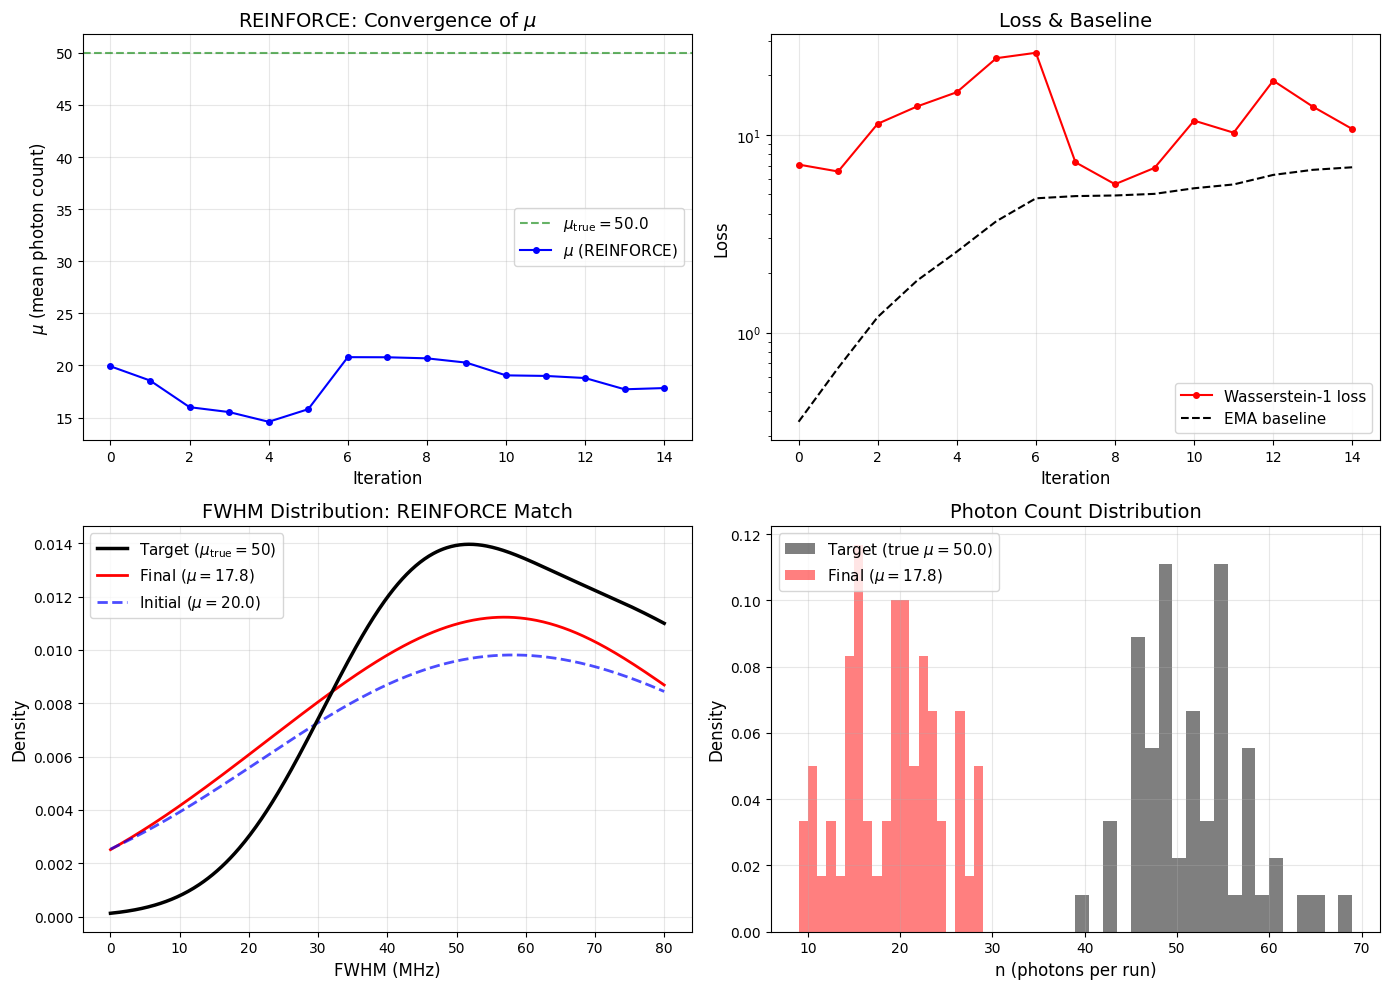


REINFORCE Results
  True mu:        50.0
  Initial mu:     20.0
  Final mu:       17.8
  Final loss:     10.7121
  Final baseline: 6.8628
  Mean n (final): 18.7
  Mean n (target): 51.4


In [8]:
# ===================== Results & Visualization =====================
steps = [h[0] for h in history]
mu_vals = [h[1] for h in history]
loss_vals = [h[2] for h in history]
baseline_vals = [h[3] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: mu convergence ---
ax = axes[0, 0]
ax.axhline(MU_TRUE, color='g', ls='--', alpha=0.6, label=f'$\\mu_{{\\mathrm{{true}}}} = {MU_TRUE}$')
ax.plot(steps, mu_vals, 'b-o', markersize=4, linewidth=1.5, label=r'$\mu$ (REINFORCE)')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel(r'$\mu$ (mean photon count)', fontsize=12)
ax.set_title(r'REINFORCE: Convergence of $\mu$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 2: Loss & baseline ---
ax = axes[0, 1]
ax.semilogy(steps, loss_vals, 'r-o', markersize=4, linewidth=1.5, label='Wasserstein-1 loss')
ax.semilogy(steps, baseline_vals, 'k--', linewidth=1.5, label='EMA baseline')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Loss & Baseline', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 3: Final FWHM distribution comparison ---
ax = axes[1, 0]
# Run final forward pass at optimized mu
final_fwhms, _, final_ns = simulate_batch(mu.detach(), N_RUNS, params, seed=999)

from scipy.stats import gaussian_kde
x_grid = np.linspace(0, 80, 500)
kde_target = gaussian_kde(target_fwhms.numpy())
kde_final = gaussian_kde(final_fwhms.numpy())
kde_init = gaussian_kde(
    simulate_batch(torch.tensor([MU_INIT]), N_RUNS, params, seed=999)[0].numpy()
)

ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=r'Target ($\mu_{\mathrm{true}}=50$)', zorder=10)
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2, label=ff'Final ($\\mu={mu.item():.1f}$)')
ax.plot(x_grid, kde_init(x_grid), 'b--', linewidth=2, alpha=0.7, label=ff'Initial ($\\mu={MU_INIT}$)')
ax.set_xlabel('FWHM (MHz)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('FWHM Distribution: REINFORCE Match', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 4: n distribution comparison ---
ax = axes[1, 1]
final_ns_arr = np.array(final_ns)
target_ns = []
rng_t = np.random.default_rng(2026)
for _ in range(N_TARGET_RUNS):
    n = max(round(MU_TRUE + params.sigma_n * rng_t.standard_normal()), 0)
    target_ns.append(n)
target_ns = np.array(target_ns)

ax.hist(target_ns, bins=20, alpha=0.5, color='k', label=ff'Target (true $\\mu={MU_TRUE}$)', density=True)
ax.hist(final_ns_arr, bins=20, alpha=0.5, color='r', label=ff'Final ($\\mu={mu.item():.1f}$)', density=True)
ax.set_xlabel('n (photons per run)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Photon Count Distribution', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary ---
print(f"\n{'='*50}")
print(f"REINFORCE Results")
print(f"{'='*50}")
print(f"  True mu:        {MU_TRUE:.1f}")
print(f"  Initial mu:     {MU_INIT:.1f}")
print(f"  Final mu:       {mu.item():.1f}")
print(f"  Final loss:     {loss_vals[-1]:.4f}")
print(f"  Final baseline: {baseline:.4f}")
print(f"  Mean n (final): {np.mean(final_ns):.1f}")
print(f"  Mean n (target): {np.mean(target_ns):.1f}")
